In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("EDA notebook ready")

EDA notebook ready


In [11]:
import os
import hopsworks
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

True

In [27]:
HOPSWORKS_KEY = os.getenv("HOPSWORKS_API_KEY")

project = hopsworks.login(
    host="eu-west.cloud.hopsworks.ai",
    project="aqi_project_10pearls",
    api_key_value=HOPSWORKS_KEY
)

fs = project.get_feature_store()

fg = fs.get_feature_group(
    name="aqi_features",
    version=1
)

df = fg.read()
df.head()

2026-05-15 16:44:11,879 INFO: Closing external client and cleaning up certificates.
2026-05-15 16:44:11,883 INFO: Connection closed.
2026-05-15 16:44:11,883 INFO: Initializing external client
2026-05-15 16:44:11,883 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-05-15 16:44:14,187 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32913
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (7.70s) 


,timestamp,city,aqi,pm25,pm10,o3,no2,so2,co,temp,...,hour_sin,hour_cos,month_sin,month_cos,aqi_change_rate,aqi_rolling_6h,aqi_rolling_24h,target_aqi_3h,target_aqi_24h,target_aqi_72h
0,2026-05-04 03:00:00+00:00,Karachi,125.0,29.99,85.19,110.59,0.36,0.53,128.01,32.6,...,0.707107,0.707107,5.000000e-01,-8.660254e-01,0.0,150.0,139.583333,125.0,125.0,125.0
1,2025-12-25 05:00:00+00:00,Karachi,125.0,44.68,79.67,122.92,1.75,10.03,310.01,19.8,...,0.965926,0.258819,-2.449294e-16,1.000000e+00,0.0,125.0,147.916667,175.0,125.0,300.0
2,2025-10-20 15:00:00+00:00,Karachi,125.0,30.25,74.14,95.38,0.17,0.64,130.01,28.1,...,-0.707107,-0.707107,-8.660254e-01,5.000000e-01,0.0,125.0,125.000000,125.0,175.0,300.0
3,2026-03-31 21:00:00+00:00,Karachi,125.0,9.71,28.13,115.39,0.15,0.44,116.11,24.0,...,-0.707107,0.707107,1.000000e+00,6.123234e-17,0.0,125.0,125.000000,125.0,125.0,125.0
4,2025-11-02 00:00:00+00:00,Karachi,175.0,58.80,113.56,99.19,0.10,0.46,180.71,23.1,...,0.000000,1.000000,-5.000000e-01,8.660254e-01,0.0,175.0,227.083333,175.0,300.0,175.0


Data Summary

In [13]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.info()

Shape: (8589, 28)
Columns: ['timestamp', 'city', 'aqi', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temp', 'humidity', 'pressure', 'wind_speed', 'wind_deg', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'aqi_change_rate', 'aqi_rolling_6h', 'aqi_rolling_24h', 'target_aqi_3h', 'target_aqi_24h', 'target_aqi_72h']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8589 entries, 0 to 8588
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype                  
---  ------           --------------  -----                  
 0   timestamp        8589 non-null   datetime64[us, Etc/UTC]
 1   city             8589 non-null   object                 
 2   aqi              8589 non-null   float64                
 3   pm25             8589 non-null   float64                
 4   pm10             8589 non-null   float64                
 5   o3               8589 non-null   float64                
 6   no2              8589 non-null 

Null Values

In [14]:
df.isnull().sum().sort_values(ascending=False)

target_aqi_72h     46
target_aqi_24h     21
city                0
target_aqi_3h       0
aqi_rolling_24h     0
aqi_rolling_6h      0
aqi_change_rate     0
month_cos           0
month_sin           0
hour_cos            0
hour_sin            0
is_weekend          0
month               0
day_of_week         0
timestamp           0
wind_deg            0
wind_speed          0
pressure            0
humidity            0
temp                0
co                  0
so2                 0
no2                 0
o3                  0
pm10                0
pm25                0
aqi                 0
hour                0
dtype: int64

In [15]:
df_clean = df.dropna(subset=["target_aqi_24h", "target_aqi_72h"])

print("Original shape:", df.shape)
print("After dropping missing target rows:", df_clean.shape)

Original shape: (8589, 28)
After dropping missing target rows: (8543, 28)


AQI Stats

In [17]:
df["aqi"].describe()

count    8589.000000
mean      139.098149
std        63.890196
min        25.000000
25%       125.000000
50%       125.000000
75%       175.000000
max       300.000000
Name: aqi, dtype: float64

AQI Distribution

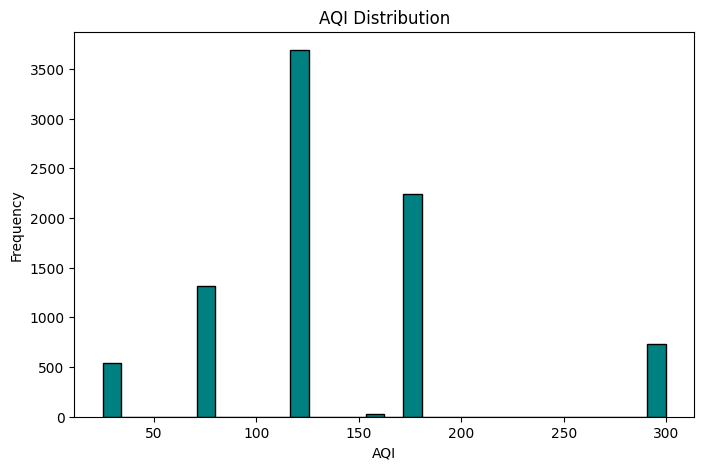

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["aqi"].dropna(), bins=30, color="teal", edgecolor="black")
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

AQI Trend Over Time

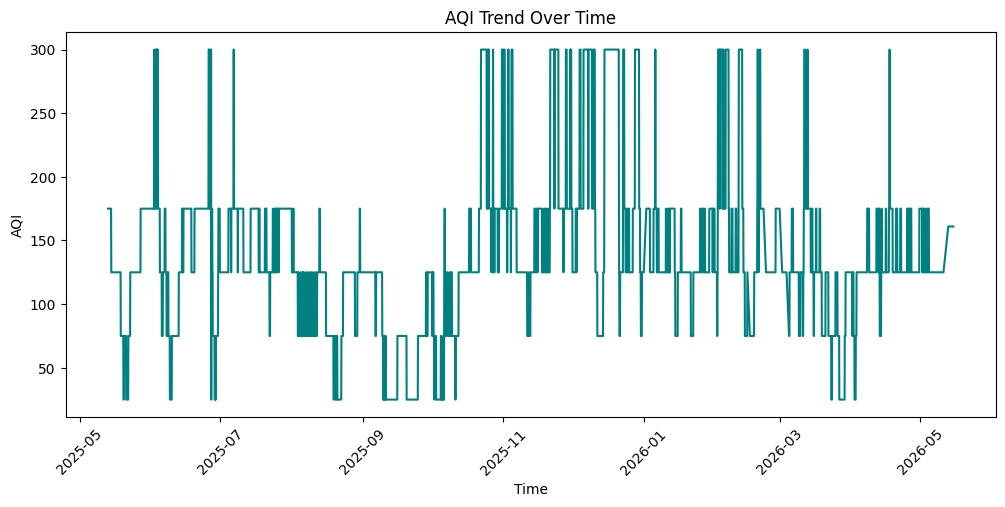

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(df_sorted["timestamp"], df_sorted["aqi"], color="teal")
plt.title("AQI Trend Over Time")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.show()

Correlation Heatmap

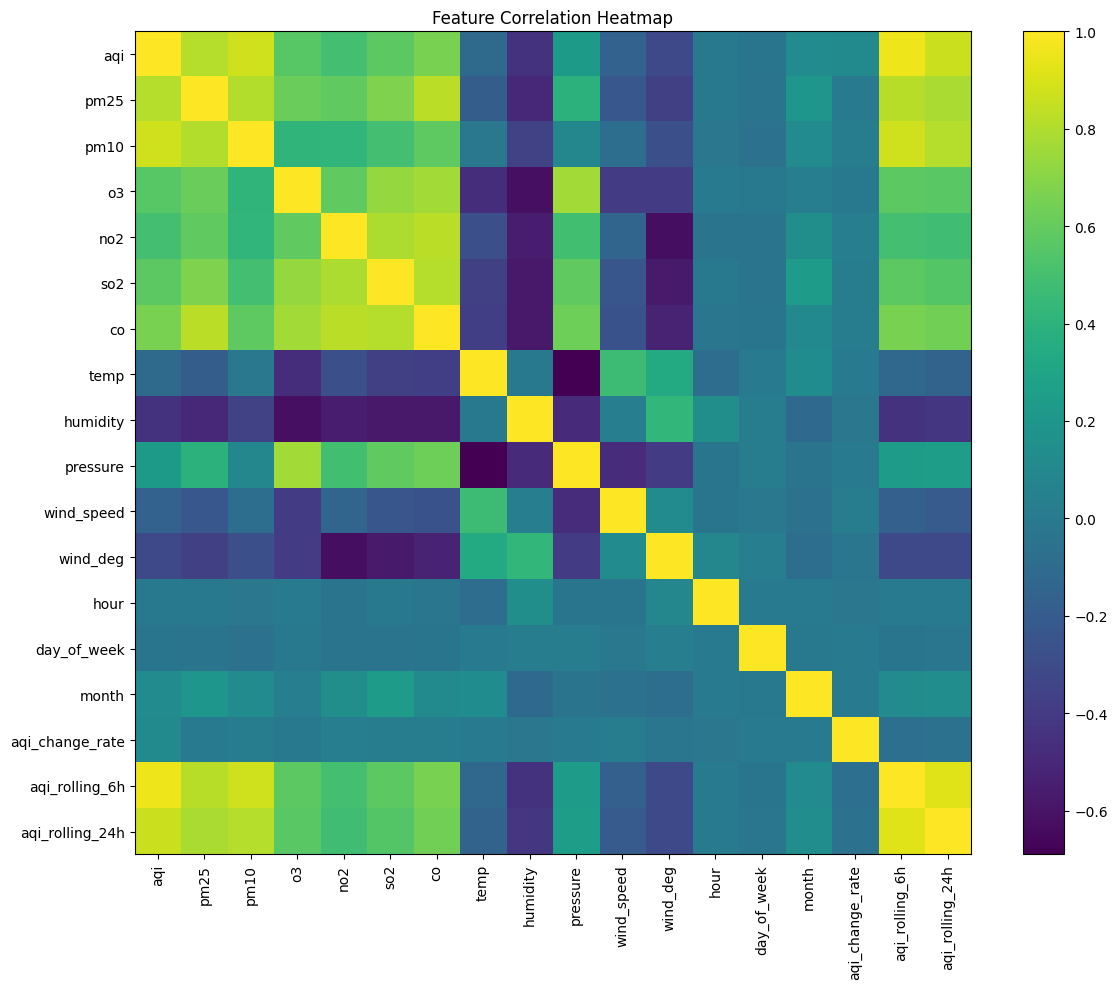

In [30]:
corr_cols = [
    "aqi", "pm25", "pm10", "o3", "no2", "so2", "co",
    "temp", "humidity", "pressure", "wind_speed", "wind_deg",
    "hour", "day_of_week", "month",
    "aqi_change_rate", "aqi_rolling_6h", "aqi_rolling_24h"
]

corr = df_clean[corr_cols].corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap="viridis", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

Average AQI by Hour

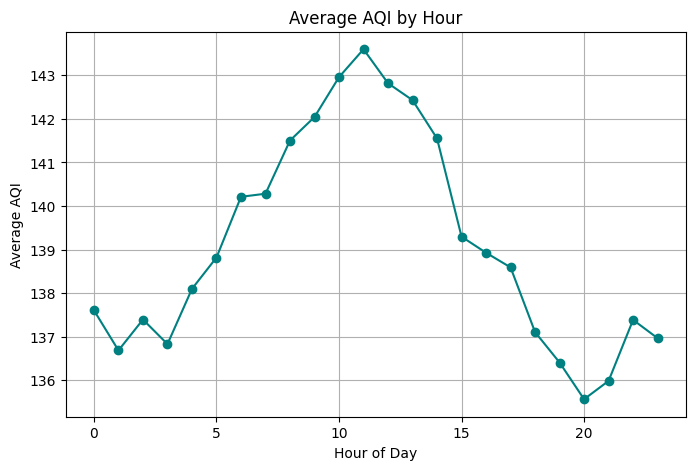

In [31]:
hourly_aqi = df_clean.groupby("hour")["aqi"].mean()
plt.figure(figsize=(8, 5))
plt.plot(hourly_aqi.index, hourly_aqi.values, marker="o", color="teal")
plt.title("Average AQI by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average AQI")
plt.grid(True)
plt.show()

Average AQI by Month

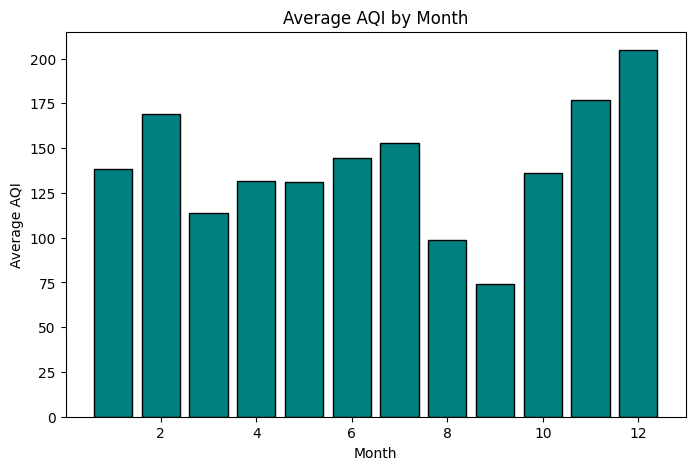

In [33]:
monthly_aqi = df_clean.groupby("month")["aqi"].mean()

plt.figure(figsize=(8, 5))
plt.bar(monthly_aqi.index, monthly_aqi.values, color="teal", edgecolor="black")
plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.show()

Pollutants vs AQI

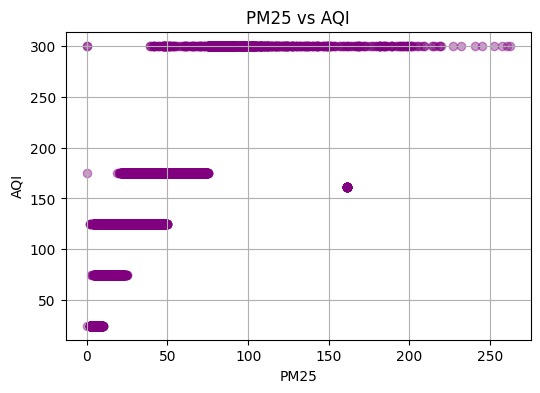

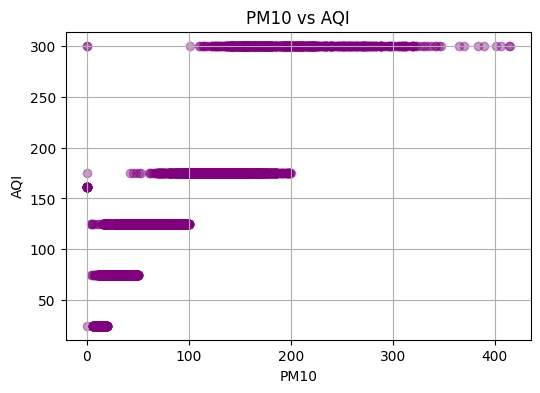

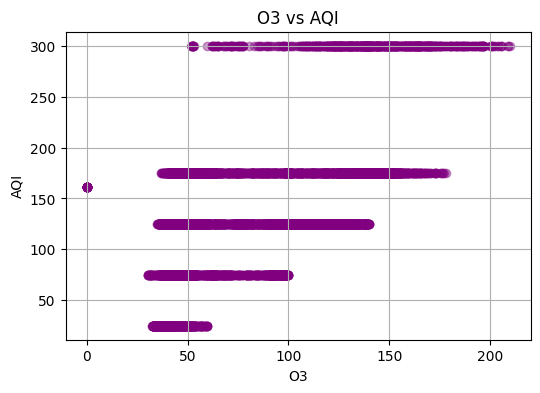

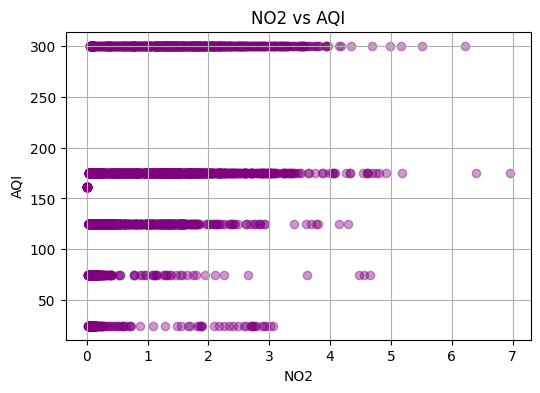

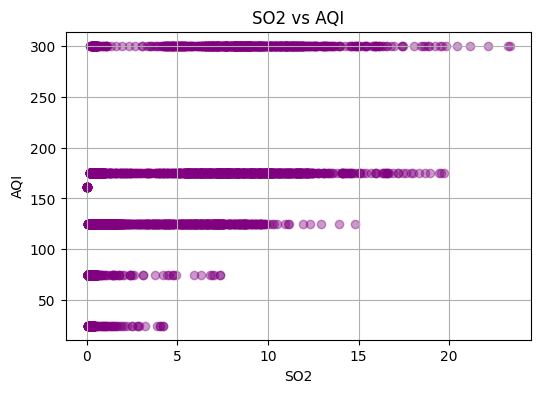

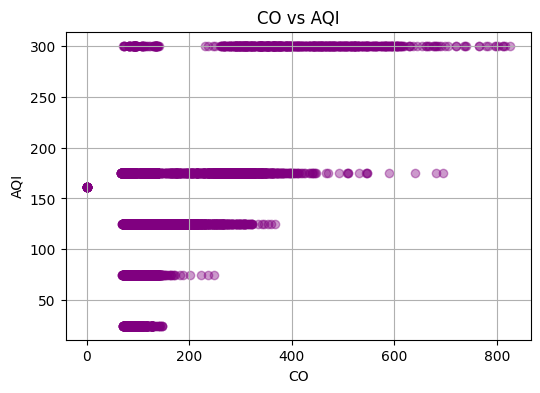

In [34]:
pollutants = ["pm25", "pm10", "o3", "no2", "so2", "co"]

for col in pollutants:
    plt.figure(figsize=(6, 4))
    plt.scatter(df_clean[col], df_clean["aqi"], alpha=0.4, color="purple")
    plt.title(f"{col.upper()} vs AQI")
    plt.xlabel(col.upper())
    plt.ylabel("AQI")
    plt.grid(True)
    plt.show()